In [1]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
from matplotlib.patches import Patch

%load_ext autoreload
%autoreload 2

ROOT = Path().cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

In [2]:
FILES = {
    'q88_W1_fc':      'results/mas/20260520_120433_gpqa_mistral-medium_N4_T15_W1_topofc_temp0.7_q88_R50_es3.json',
    'q88_W1_star':    'results/mas/20260520_122051_gpqa_mistral-medium_N4_T15_W1_topostar_temp0.7_q88_R50_es3.json',
    'q88_W5_fc':      'results/mas/20260520_124235_gpqa_mistral-medium_N4_T15_W5_topofc_temp0.7_q88_R50_es3.json',
    'q88_W5_star':    'results/mas/20260520_130024_gpqa_mistral-medium_N4_T15_W5_topostar_temp0.7_q88_R50_es3.json',
}

data = {name: json.load(open(ROOT / path)) for name, path in FILES.items()}

for name, d in data.items():
    R = len(d['repetitions'])
    print(f"{name:20s}  q={d['question_id']}  W={d['W']}  topo={d['topology_name']:4s}  GT={d['ground_truth']}  R={R}")

q88_W1_fc             q=88  W=1  topo=fc    GT=A  R=50
q88_W1_star           q=88  W=1  topo=star  GT=A  R=50
q88_W5_fc             q=88  W=5  topo=fc    GT=A  R=50
q88_W5_star           q=88  W=5  topo=star  GT=A  R=50


## Helper functions

In [3]:
def votes_at(rep, round_idx):
    return [a['vote'] for a in rep['trajectory'][round_idx]['phase_b']]

def is_correct_at(rep, round_idx):
    gt = rep['ground_truth']
    return [v == gt for v in votes_at(rep, round_idx)]

def majority_vote(rep, round_idx):
    vs = votes_at(rep, round_idx)
    return max(set(vs), key=vs.count)

def is_unanimous(rep, round_idx):
    return len(set(votes_at(rep, round_idx))) == 1

def unanimity_seq(rep):
    return [is_unanimous(rep, t) for t in range(len(rep['trajectory']))]

def frac_correct_per_round(d):
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    per_round = []
    for t in range(T):
        vals = [np.mean(is_correct_at(rep, t)) for rep in d['repetitions'] if t < len(rep['trajectory'])]
        per_round.append(np.mean(vals))
    return per_round

def frac_unanimous_per_round(d):
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    per_round = []
    for t in range(T):
        vals = [is_unanimous(rep, t) for rep in d['repetitions'] if t < len(rep['trajectory'])]
        per_round.append(np.mean(vals))
    return per_round

COLORS = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860'
]

## 1. Accuracy overview — all 6 runs

             agent_acc_t0  agent_acc_final  system_correct  majority_correct
run                                                                         
q88_W1_fc           0.405             0.39            0.38              0.40
q88_W1_star         0.420             0.34            0.34              0.34
q88_W5_fc           0.460             0.46            0.46              0.46
q88_W5_star         0.415             0.40            0.40              0.40


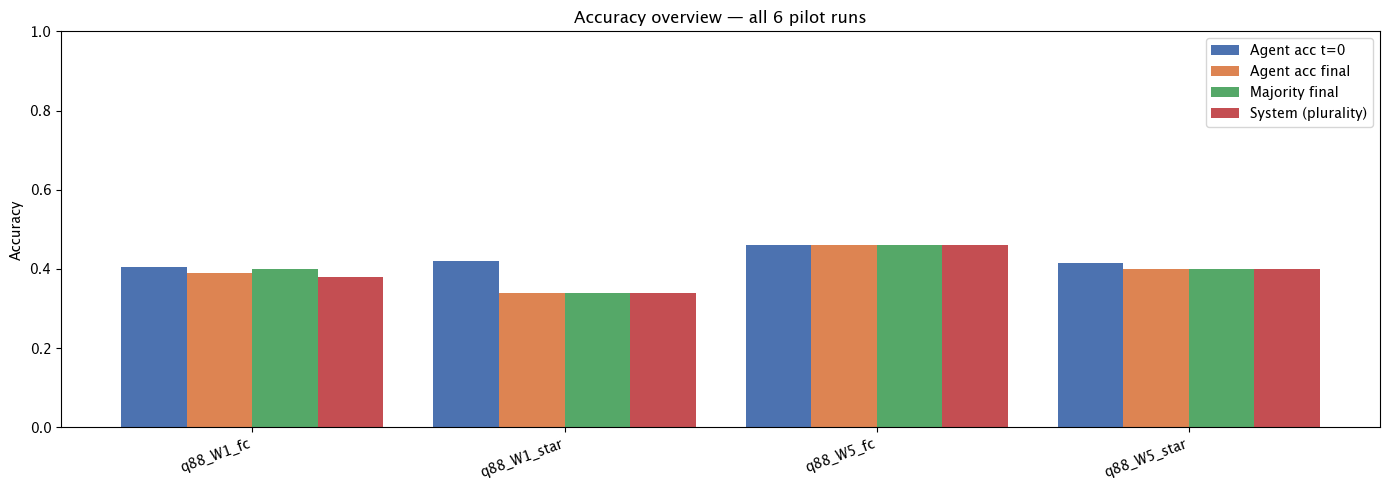

In [5]:
acc_records = []
for name, d in data.items():
    for rep in d['repetitions']:
        acc_records.append({
            'run': name,
            'q': d['question_id'],
            'W': d['W'],
            'topo': d['topology_name'],
            'agent_acc_t0': np.mean(is_correct_at(rep, 0)),
            'agent_acc_final': np.mean(is_correct_at(rep, -1)),
            'system_correct': float(rep['correct']),
            'majority_correct': float(majority_vote(rep, -1) == rep['ground_truth']),
        })

acc_df = pd.DataFrame(acc_records)

summary = acc_df.groupby('run')[['agent_acc_t0', 'agent_acc_final', 'system_correct', 'majority_correct']].mean()
print(summary.round(3).to_string())

runs = list(summary.index)
x = np.arange(len(runs))
width = 0.21
metrics = [
    ('agent_acc_t0',    'Agent acc t=0',      '#4C72B0'),
    ('agent_acc_final', 'Agent acc final',    '#DD8452'),
    ('majority_correct','Majority final',     '#55A868'),
    ('system_correct',  'System (plurality)', '#C44E52'),
]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (col, label, color) in enumerate(metrics):
    ax.bar(x + i * width, summary[col], width, label=label, color=color)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(runs, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy overview — all 6 pilot runs')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Vote dynamics over rounds — accuracy & consensus

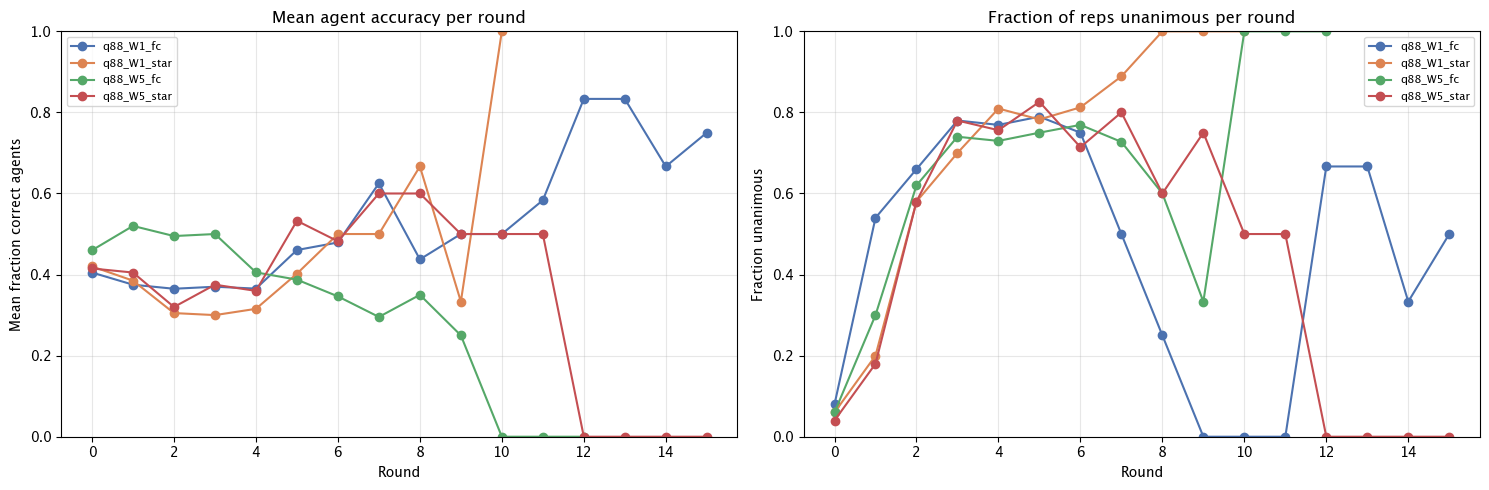

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for (name, d), color in zip(data.items(), COLORS):
    fc = frac_correct_per_round(d)
    fu = frac_unanimous_per_round(d)
    rounds = range(len(fc))
    axes[0].plot(rounds, fc, marker='o', label=name, color=color)
    axes[1].plot(rounds, fu, marker='o', label=name, color=color)

for ax, title, ylabel in zip(
    axes,
    ['Mean agent accuracy per round', 'Fraction of reps unanimous per round'],
    ['Mean fraction correct agents', 'Fraction unanimous'],
):
    ax.set_xlabel('Round')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Final vote distribution per run

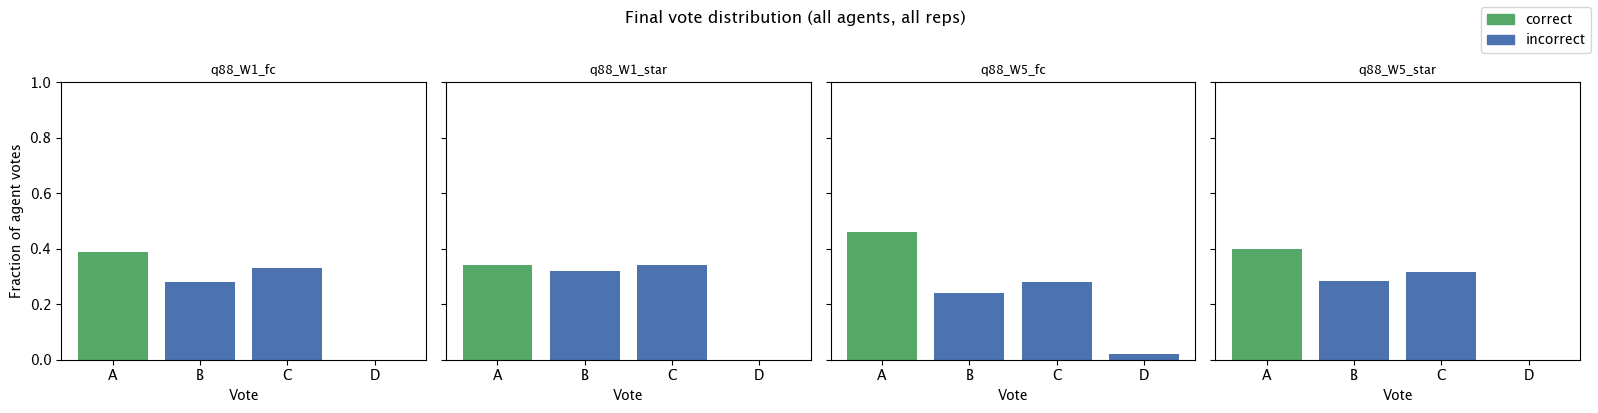

In [7]:
n = len(data)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)

for ax, (name, d) in zip(axes, data.items()):
    gt = d['ground_truth']
    opts = sorted(d['repetitions'][0]['options'].keys())
    vote_counts = defaultdict(int)
    for rep in d['repetitions']:
        for v in votes_at(rep, -1):
            vote_counts[v] += 1
    total = sum(vote_counts.values())
    fracs = [vote_counts.get(o, 0) / total for o in opts]
    colors = ['#55A868' if o == gt else '#4C72B0' for o in opts]
    ax.bar(opts, fracs, color=colors)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Vote')

axes[0].set_ylabel('Fraction of agent votes')
fig.legend(
    handles=[Patch(color='#55A868', label='correct'), Patch(color='#4C72B0', label='incorrect')],
    loc='upper right'
)
plt.suptitle('Final vote distribution (all agents, all reps)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Consensus evolution — when do runs reach unanimity?

             frac_ever_unanimous  frac_final_unanimous  mean_first_hit
run                                                                   
q88_W1_fc                   0.98                  0.98           1.898
q88_W1_star                 1.00                  1.00           2.660
q88_W5_fc                   1.00                  1.00           2.620
q88_W5_star                 0.98                  0.98           2.469


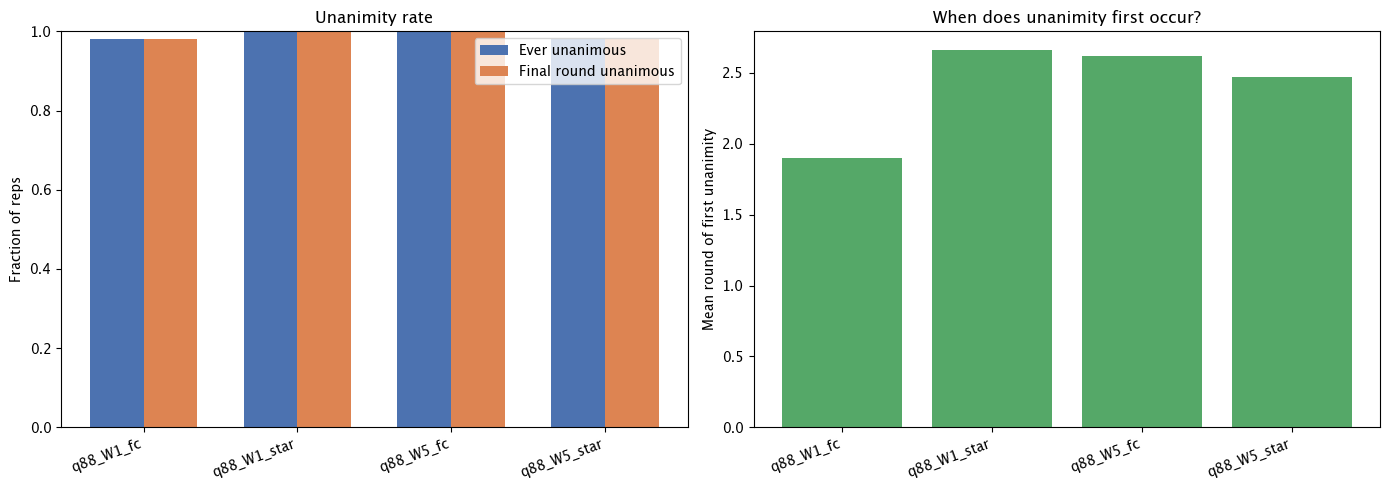

In [8]:
cons_records = []
for name, d in data.items():
    for rep in d['repetitions']:
        seq = unanimity_seq(rep)
        T = len(seq)
        first_hit = next((t for t in range(T) if seq[t]), None)
        final_unanimous = seq[-1]
        cons_records.append({
            'run': name,
            'first_unanimous_round': first_hit if first_hit is not None else -1,
            'ever_unanimous': first_hit is not None,
            'final_unanimous': final_unanimous,
            'final_correct': majority_vote(rep, -1) == rep['ground_truth'],
        })

cons_df = pd.DataFrame(cons_records)

summary_cons = cons_df.groupby('run').agg(
    frac_ever_unanimous=('ever_unanimous', 'mean'),
    frac_final_unanimous=('final_unanimous', 'mean'),
    mean_first_hit=('first_unanimous_round', lambda x: x[x >= 0].mean() if (x >= 0).any() else float('nan')),
).round(3)
print(summary_cons.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runs = list(summary_cons.index)
x = np.arange(len(runs))
width = 0.35

axes[0].bar(x - width/2, summary_cons['frac_ever_unanimous'], width, label='Ever unanimous', color='#4C72B0')
axes[0].bar(x + width/2, summary_cons['frac_final_unanimous'], width, label='Final round unanimous', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(runs, rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Fraction of reps')
axes[0].set_title('Unanimity rate')
axes[0].legend()

axes[1].bar(x, summary_cons['mean_first_hit'], color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(runs, rotation=20, ha='right')
axes[1].set_ylabel('Mean round of first unanimity')
axes[1].set_title('When does unanimity first occur?')

plt.tight_layout()
plt.show()

## 5. Effect of W (warmup rounds): W=1 vs W=5


Accuracy by W and topology (q88):
     agent_acc_t0        agent_acc_final       system_correct      
topo           fc   star              fc  star             fc  star
W                                                                  
1           0.405  0.420            0.39  0.34           0.38  0.34
5           0.460  0.415            0.46  0.40           0.46  0.40


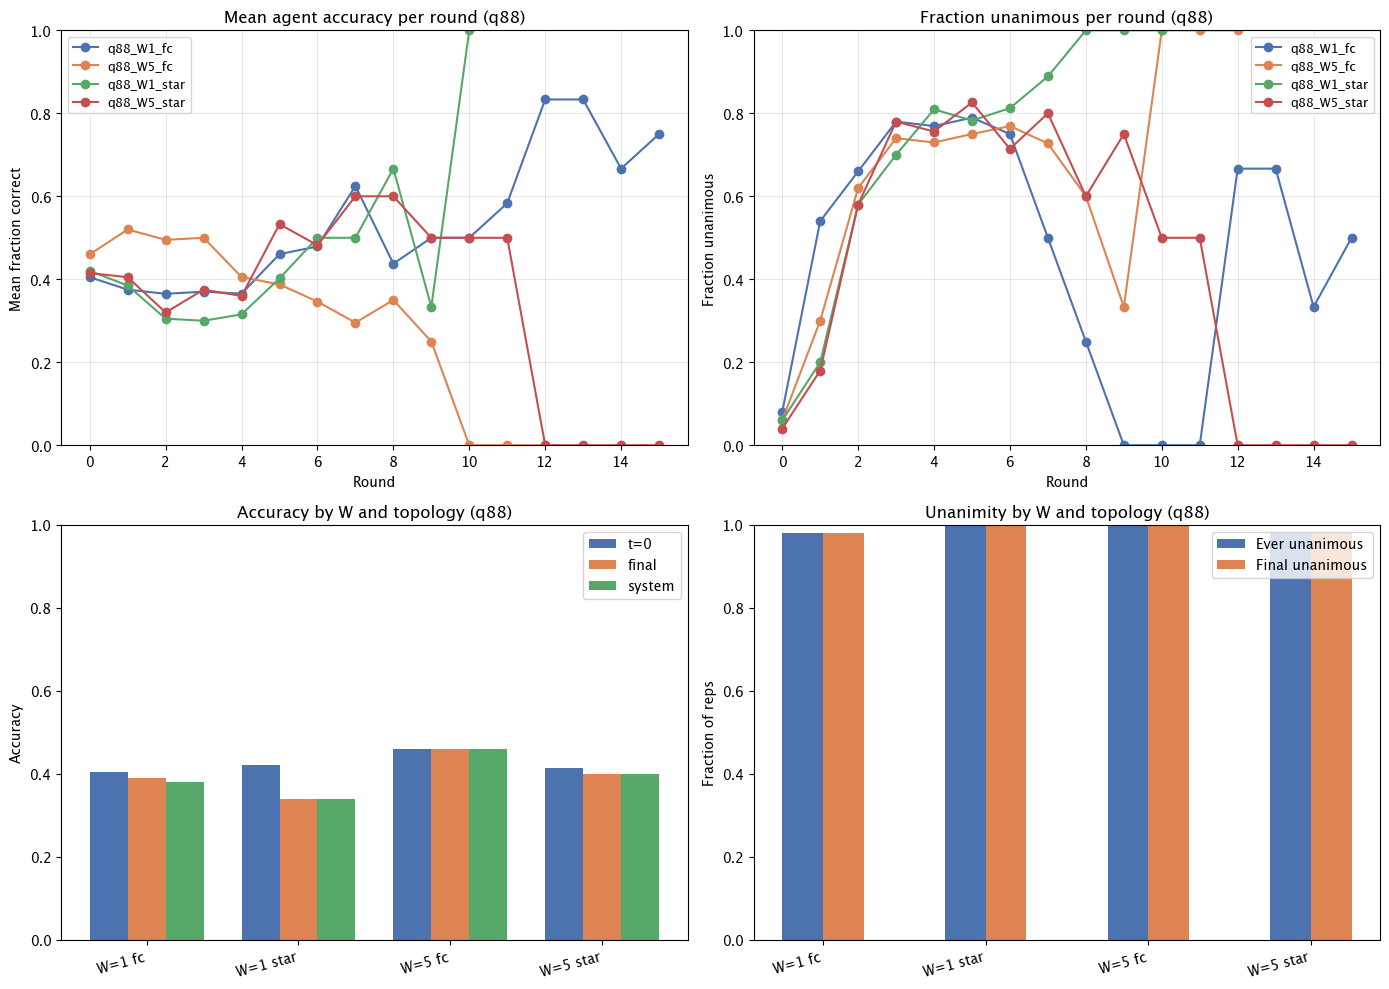

In [9]:
W_groups = {
    'q88_W1_fc':   data['q88_W1_fc'],
    'q88_W5_fc':   data['q88_W5_fc'],
    'q88_W1_star': data['q88_W1_star'],
    'q88_W5_star': data['q88_W5_star'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (name, d), color in zip(W_groups.items(), COLORS[:4]):
    fc = frac_correct_per_round(d)
    fu = frac_unanimous_per_round(d)
    rounds = range(len(fc))
    axes[0, 0].plot(rounds, fc, marker='o', label=name, color=color)
    axes[0, 1].plot(rounds, fu, marker='o', label=name, color=color)

for topo, (ax_top, ax_bot) in zip(['fc', 'star'], [(axes[1, 0], axes[1, 1])]):
    pass

for ax, title, ylabel in zip(
    [axes[0, 0], axes[0, 1]],
    ['Mean agent accuracy per round (q88)', 'Fraction unanimous per round (q88)'],
    ['Mean fraction correct', 'Fraction unanimous'],
):
    ax.set_xlabel('Round')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

W_acc = acc_df[acc_df['q'] == '88'].groupby(['W', 'topo'])[['agent_acc_t0', 'agent_acc_final', 'system_correct']].mean().unstack('topo')
print("\nAccuracy by W and topology (q88):")
print(W_acc.round(3).to_string())

W_labels = ['W=1 fc', 'W=1 star', 'W=5 fc', 'W=5 star']
run_keys = ['q88_W1_fc', 'q88_W1_star', 'q88_W5_fc', 'q88_W5_star']
x = np.arange(len(run_keys))
width = 0.25

sub = acc_df[acc_df['run'].isin(run_keys)].groupby('run')[['agent_acc_t0', 'agent_acc_final', 'system_correct']].mean().reindex(run_keys)

for i, (col, label, color) in enumerate([('agent_acc_t0','t=0','#4C72B0'), ('agent_acc_final','final','#DD8452'), ('system_correct','system','#55A868')]):
    axes[1, 0].bar(x + i * width, sub[col], width, label=label, color=color)

axes[1, 0].set_xticks(x + width)
axes[1, 0].set_xticklabels(W_labels, rotation=15, ha='right')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy by W and topology (q88)')
axes[1, 0].legend()

cons_sub = cons_df[cons_df['run'].isin(run_keys)].groupby('run').agg(
    frac_ever_unanimous=('ever_unanimous', 'mean'),
    frac_final_unanimous=('final_unanimous', 'mean'),
).reindex(run_keys)

axes[1, 1].bar(x - width/2, cons_sub['frac_ever_unanimous'], width, label='Ever unanimous', color='#4C72B0')
axes[1, 1].bar(x + width/2, cons_sub['frac_final_unanimous'], width, label='Final unanimous', color='#DD8452')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(W_labels, rotation=15, ha='right')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel('Fraction of reps')
axes[1, 1].set_title('Unanimity by W and topology (q88)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Topology effect: fully-connected vs star

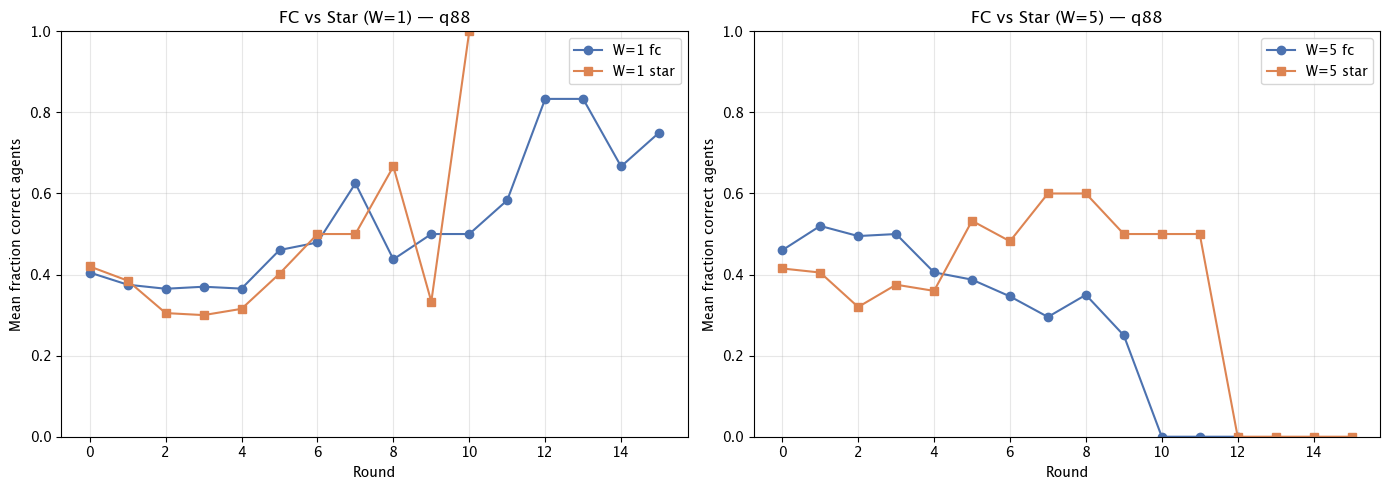

In [10]:
pairs = [
    ('q88_W1_fc', 'q88_W1_star', 'W=1'),
    ('q88_W5_fc', 'q88_W5_star', 'W=5'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fc_key, star_key, label) in zip(axes, pairs):
    fc_correct = frac_correct_per_round(data[fc_key])
    star_correct = frac_correct_per_round(data[star_key])
    rounds = range(max(len(fc_correct), len(star_correct)))
    ax.plot(range(len(fc_correct)), fc_correct, marker='o', label=f'{label} fc', color='#4C72B0')
    ax.plot(range(len(star_correct)), star_correct, marker='s', label=f'{label} star', color='#DD8452')
    ax.set_xlabel('Round')
    ax.set_ylabel('Mean fraction correct agents')
    ax.set_title(f'FC vs Star ({label}) — q88')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Reproducibility: q75 re-run comparison (v1 vs v2)

KeyError: 'q75_W1_fc_v1'

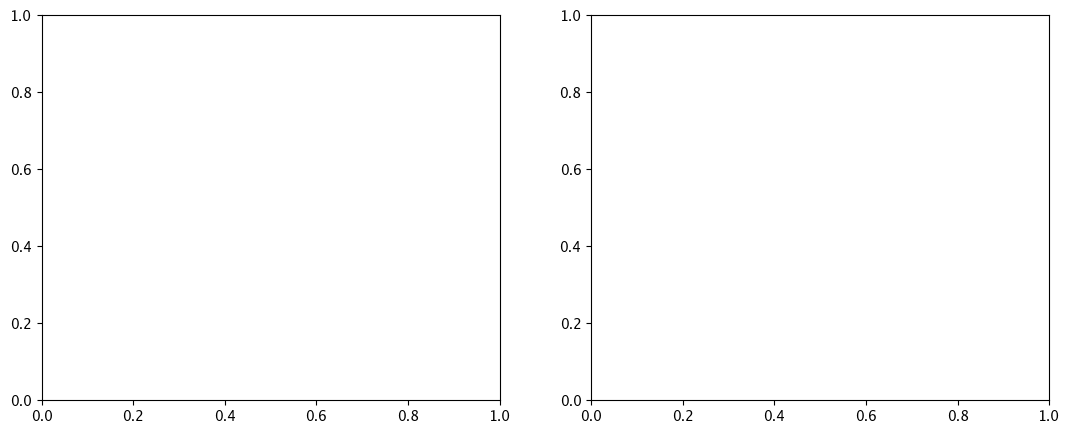

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, color in [('q75_W1_fc_v1', '#4C72B0'), ('q75_W1_fc_v2', '#DD8452')]:
    d = data[name]
    fc = frac_correct_per_round(d)
    fu = frac_unanimous_per_round(d)
    axes[0].plot(range(len(fc)), fc, marker='o', label=name, color=color)
    axes[1].plot(range(len(fu)), fu, marker='o', label=name, color=color)

for ax, title, ylabel in zip(
    axes,
    ['Agent accuracy per round — q75 re-run', 'Unanimity per round — q75 re-run'],
    ['Mean fraction correct', 'Fraction unanimous'],
):
    ax.set_xlabel('Round')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

v1_sys = np.mean([rep['correct'] for rep in data['q75_W1_fc_v1']['repetitions']])
v2_sys = np.mean([rep['correct'] for rep in data['q75_W1_fc_v2']['repetitions']])
print(f'q75_W1_fc_v1 system accuracy: {v1_sys:.3f}')
print(f'q75_W1_fc_v2 system accuracy: {v2_sys:.3f}')
print(f'Difference: {abs(v1_sys - v2_sys):.4f}')

## 8. State-level analysis — correct-count Markov chain (all 6 runs)

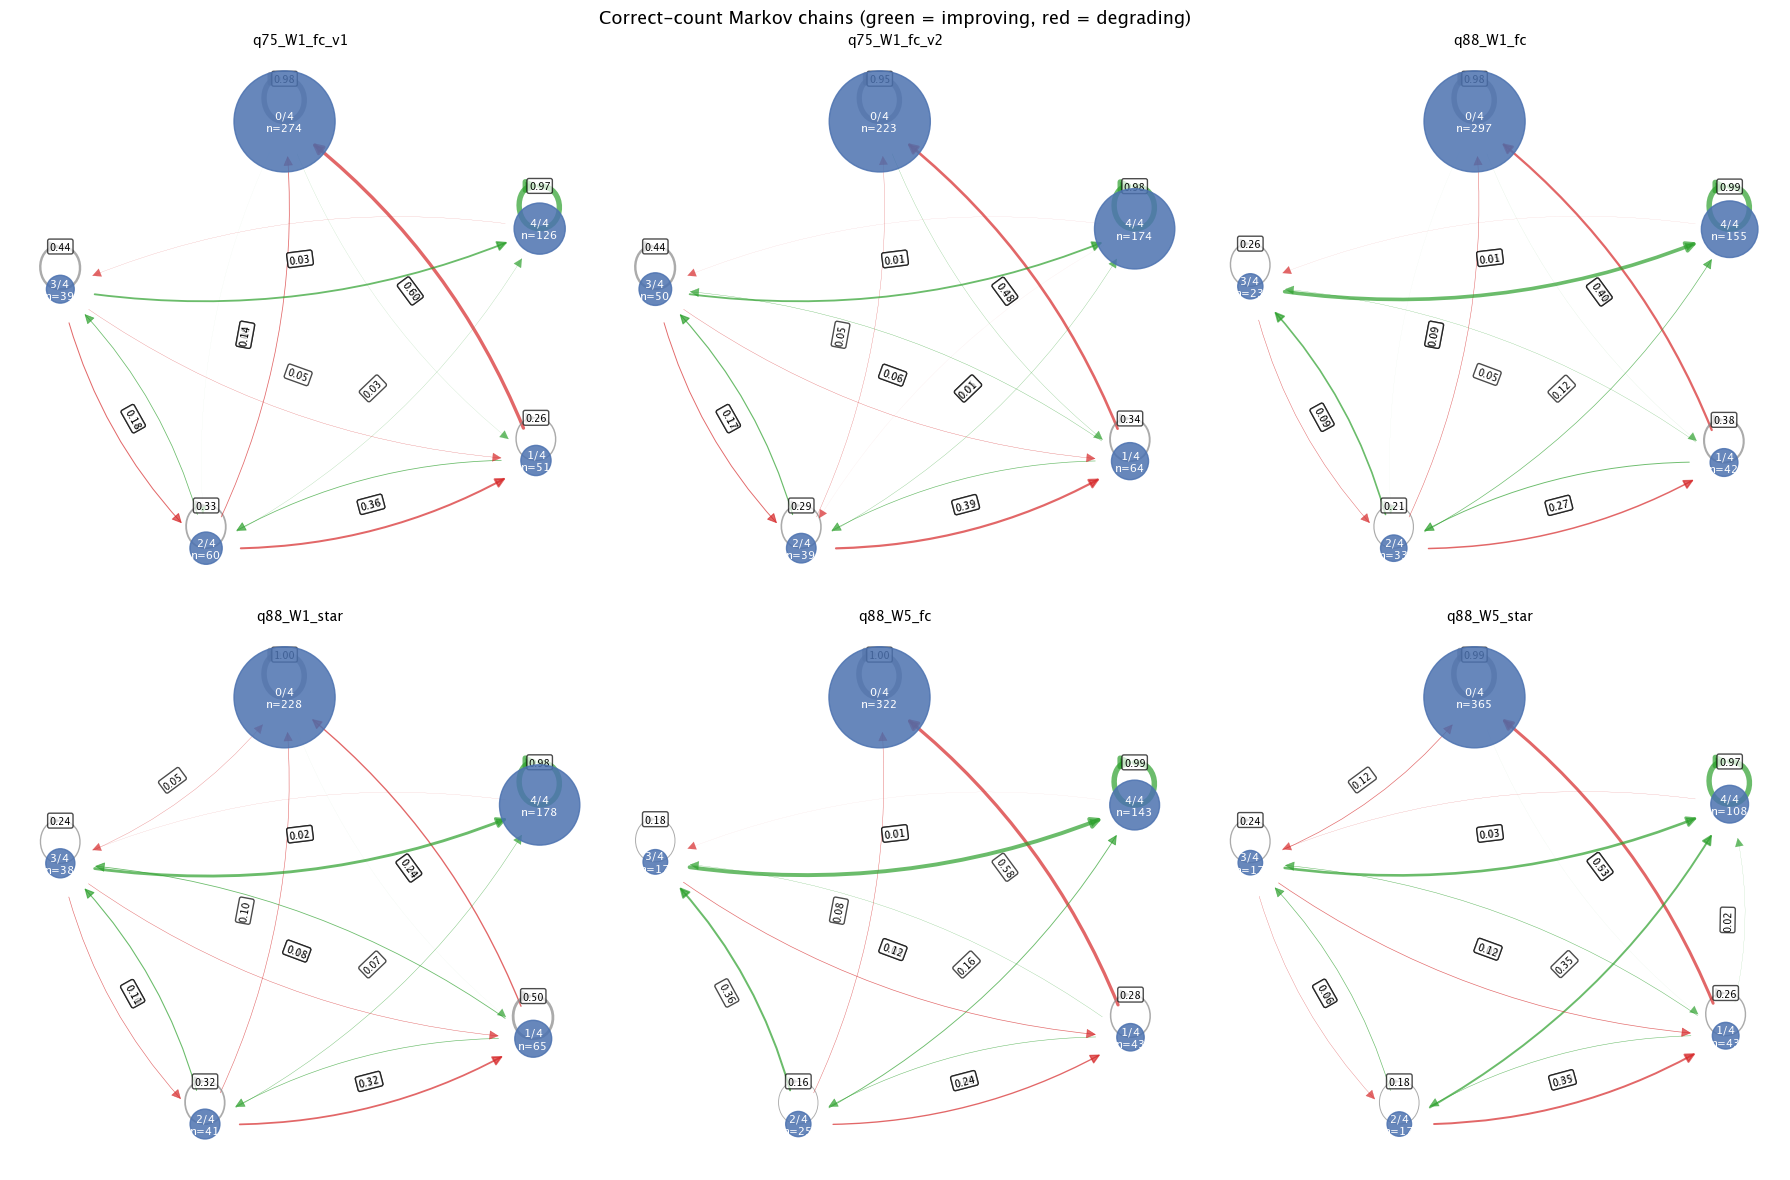

In [ ]:
def build_correct_count_graph(d):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)
    gt = d['ground_truth']

    for rep in d['repetitions']:
        states = [
            sum(1 for a in step['phase_b'] if a['vote'] == gt)
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    N = d['repetitions'][0]['N']
    G = nx.DiGraph()
    for k in range(N + 1):
        G.add_node(k, visits=visit_counts.get(k, 0))
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, cnt in to_dict.items():
            G.add_edge(from_s, to_s, weight=cnt / total)
    return G, N

ARC_RAD = 0.15

def plot_correct_count_graph(G, N, title, ax):
    pos = nx.spring_layout(G, seed=42, k=4.0)
    max_vis = max(d['visits'] for _, d in G.nodes(data=True)) or 1
    node_sizes = [300 + (G.nodes[n]['visits'] / max_vis) ** 2 * 5000 for n in G.nodes()]
    node_labels = {n: f"{n}/{N}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_color_map = {}
    for u, v in G.edges():
        if u == v:
            edge_color_map[(u, v)] = '#2ca02c' if u == N else '#888888'
        elif v > u:
            edge_color_map[(u, v)] = '#2ca02c'
        else:
            edge_color_map[(u, v)] = '#d62728'
    edge_colors = [edge_color_map[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.7, edge_color=edge_colors,
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle=f'arc3,rad={ARC_RAD}',
        min_source_margin=25, min_target_margin=25,
    )
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_size=7, ax=ax,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
    )
    ax.set_title(title, fontsize=10)
    ax.axis('off')

n = len(data)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (name, d) in zip(axes, data.items()):
    G, N = build_correct_count_graph(d)
    plot_correct_count_graph(G, N, name, ax)

plt.suptitle('Correct-count Markov chains (green = improving, red = degrading)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Absorbing state analysis — where do runs end up?

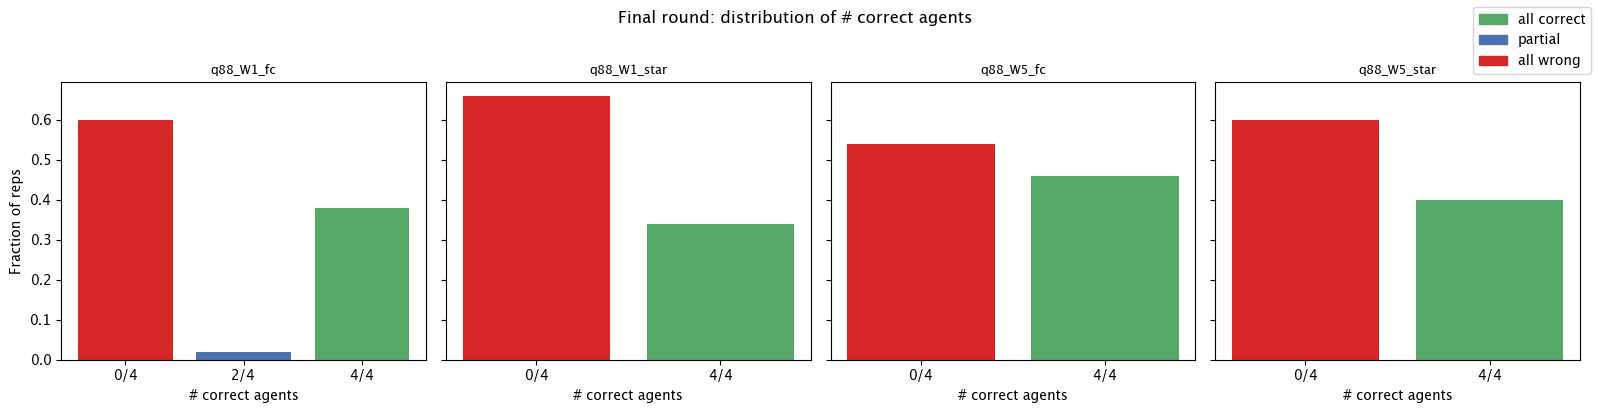

In [12]:
absorb_records = []
for name, d in data.items():
    gt = d['ground_truth']
    N = d['repetitions'][0]['N']
    for rep in d['repetitions']:
        final_votes = votes_at(rep, -1)
        n_correct = sum(v == gt for v in final_votes)
        absorb_records.append({
            'run': name,
            'n_correct': n_correct,
            'N': N,
            'is_unanimous': len(set(final_votes)) == 1,
            'is_all_correct': n_correct == N,
            'is_all_wrong': n_correct == 0,
        })

absorb_df = pd.DataFrame(absorb_records)

fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 4), sharey=True)

for ax, (name, d) in zip(axes, data.items()):
    N = d['repetitions'][0]['N']
    gt = d['ground_truth']
    sub = absorb_df[absorb_df['run'] == name]
    counts = sub['n_correct'].value_counts().sort_index()
    bar_colors = ['#55A868' if k == N else ('#d62728' if k == 0 else '#4C72B0') for k in counts.index]
    ax.bar([f"{k}/{N}" for k in counts.index], counts.values / len(sub), color=bar_colors)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('# correct agents')

axes[0].set_ylabel('Fraction of reps')
fig.legend(
    handles=[Patch(color='#55A868', label='all correct'), Patch(color='#4C72B0', label='partial'), Patch(color='#d62728', label='all wrong')],
    loc='upper right',
)
plt.suptitle('Final round: distribution of # correct agents', y=1.02)
plt.tight_layout()
plt.show()

## 10. Opinion switching — how much do agents change their vote?

             switch_rate  wrong_to_correct  correct_to_wrong  net_benefit
run                                                                      
q88_W1_fc          0.183              1.48              1.54        -0.06
q88_W1_star        0.223              1.52              1.84        -0.32
q88_W5_fc          0.196              1.68              1.68         0.00
q88_W5_star        0.251              2.08              2.14        -0.06


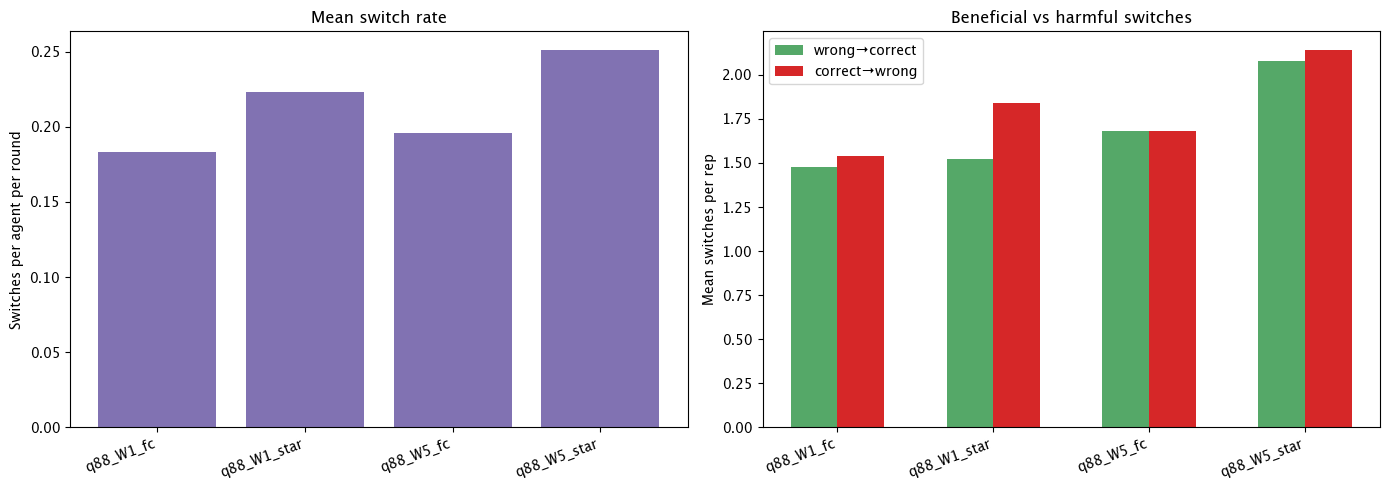

In [13]:
switch_records = []
for name, d in data.items():
    gt = d['ground_truth']
    N = d['repetitions'][0]['N']
    for rep in d['repetitions']:
        T = len(rep['trajectory'])
        total_switches = 0
        correct_to_wrong = 0
        wrong_to_correct = 0
        for t in range(1, T):
            prev = votes_at(rep, t - 1)
            curr = votes_at(rep, t)
            for a_prev, a_curr in zip(prev, curr):
                if a_prev != a_curr:
                    total_switches += 1
                    if a_prev == gt:
                        correct_to_wrong += 1
                    elif a_curr == gt:
                        wrong_to_correct += 1
        total_transitions = (T - 1) * N
        switch_records.append({
            'run': name,
            'switch_rate': total_switches / total_transitions,
            'wrong_to_correct': wrong_to_correct,
            'correct_to_wrong': correct_to_wrong,
            'net_benefit': wrong_to_correct - correct_to_wrong,
        })

switch_df = pd.DataFrame(switch_records)
switch_summary = switch_df.groupby('run')[['switch_rate', 'wrong_to_correct', 'correct_to_wrong', 'net_benefit']].mean().round(3)
print(switch_summary.to_string())

runs = list(switch_summary.index)
x = np.arange(len(runs))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x, switch_summary['switch_rate'], color='#8172B2')
axes[0].set_xticks(x)
axes[0].set_xticklabels(runs, rotation=20, ha='right')
axes[0].set_ylabel('Switches per agent per round')
axes[0].set_title('Mean switch rate')

axes[1].bar(x - width/2, switch_summary['wrong_to_correct'], width, label='wrong→correct', color='#55A868')
axes[1].bar(x + width/2, switch_summary['correct_to_wrong'], width, label='correct→wrong', color='#d62728')
axes[1].set_xticks(x)
axes[1].set_xticklabels(runs, rotation=20, ha='right')
axes[1].set_ylabel('Mean switches per rep')
axes[1].set_title('Beneficial vs harmful switches')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Summary table

In [14]:
summary_rows = []
for name, d in data.items():
    gt = d['ground_truth']
    N = d['repetitions'][0]['N']
    T_lens = [len(rep['trajectory']) for rep in d['repetitions']]
    system_acc = np.mean([rep['correct'] for rep in d['repetitions']])
    agent_acc_t0 = np.mean([np.mean(is_correct_at(rep, 0)) for rep in d['repetitions']])
    agent_acc_final = np.mean([np.mean(is_correct_at(rep, -1)) for rep in d['repetitions']])
    frac_ever_unani = np.mean([any(unanimity_seq(rep)) for rep in d['repetitions']])
    frac_final_unani = np.mean([is_unanimous(rep, -1) for rep in d['repetitions']])
    summary_rows.append({
        'run': name,
        'q': d['question_id'],
        'W': d['W'],
        'topo': d['topology_name'],
        'GT': gt,
        'agent_acc_t0': round(agent_acc_t0, 3),
        'agent_acc_final': round(agent_acc_final, 3),
        'system_acc': round(system_acc, 3),
        'frac_ever_unanimous': round(frac_ever_unani, 3),
        'frac_final_unanimous': round(frac_final_unani, 3),
    })

summary_table = pd.DataFrame(summary_rows).set_index('run')
summary_table

,q,W,topo,GT,agent_acc_t0,agent_acc_final,system_acc,frac_ever_unanimous,frac_final_unanimous
run,,,,,,,,,
q88_W1_fc,88,1,fc,A,0.405,0.39,0.38,0.98,0.98
q88_W1_star,88,1,star,A,0.420,0.34,0.34,1.00,1.00
q88_W5_fc,88,5,fc,A,0.460,0.46,0.46,1.00,1.00
q88_W5_star,88,5,star,A,0.415,0.40,0.40,0.98,0.98


=== Frobenius distance ===
             q88_W1_fc  q88_W1_star  q88_W5_fc  q88_W5_star
q88_W1_fc       0.0000       0.3996     0.3847       0.3797
q88_W1_star     0.3996       0.0000     0.2368       0.3172
q88_W5_fc       0.3847       0.2368     0.0000       0.3508
q88_W5_star     0.3797       0.3172     0.3508       0.0000

=== JS divergence (stationary-weighted, symmetric) ===
             q88_W1_fc  q88_W1_star  q88_W5_fc  q88_W5_star
q88_W1_fc       0.0000       0.0223     0.0117       0.0213
q88_W1_star     0.0223       0.0000     0.0128       0.0179
q88_W5_fc       0.0117       0.0128     0.0000       0.0195
q88_W5_star     0.0213       0.0179     0.0195       0.0000


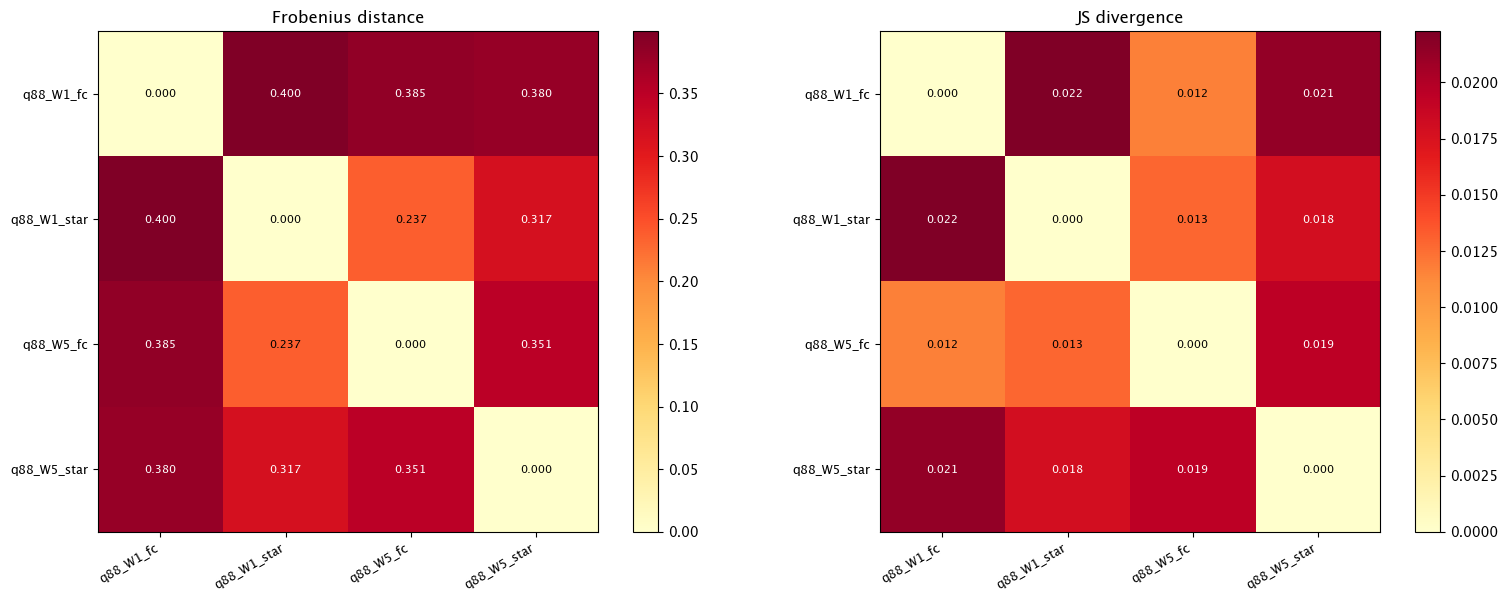

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import rel_entr

N_STATES = 5  # states 0..4 (N=4 agents)

def build_transition_matrix(d):
    gt = d['ground_truth']
    counts = np.zeros((N_STATES, N_STATES))
    visit_counts = np.zeros(N_STATES)
    for rep in d['repetitions']:
        states = [sum(1 for a in step['phase_b'] if a['vote'] == gt) for step in rep['trajectory']]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            counts[s1, s2] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    T = counts / row_sums
    return T, visit_counts / visit_counts.sum()

matrices = {name: build_transition_matrix(d) for name, d in data.items()}
names = list(matrices.keys())
n = len(names)

def frobenius(T1, T2):
    return np.linalg.norm(T1 - T2, 'fro')

def weighted_kl(T_p, pi_p, T_q):
    eps = 1e-10
    kl_per_row = np.sum(rel_entr(T_p + eps, T_q + eps), axis=1)  # rel_entr(p,q) = p*log(p/q)
    return float(pi_p @ kl_per_row)

def js_divergence(T_p, pi_p, T_q, pi_q):
    pi_avg = (pi_p + pi_q) / 2
    return 0.5 * weighted_kl(T_p, pi_avg, (T_p + T_q) / 2) + \
           0.5 * weighted_kl(T_q, pi_avg, (T_p + T_q) / 2)

frob_mat = np.zeros((n, n))
js_mat   = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        Ti, pi_i = matrices[ni]
        Tj, pi_j = matrices[nj]
        frob_mat[i, j] = frobenius(Ti, Tj)
        js_mat[i, j]   = js_divergence(Ti, pi_i, Tj, pi_j)

frob_df = pd.DataFrame(frob_mat, index=names, columns=names).round(4)
js_df   = pd.DataFrame(js_mat,   index=names, columns=names).round(4)

print("=== Frobenius distance ===")
print(frob_df.to_string())
print("\n=== JS divergence (stationary-weighted, symmetric) ===")
print(js_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(axes, [frob_mat, js_mat], ['Frobenius distance', 'JS divergence']):
    im = ax.imshow(mat, cmap='YlOrRd')
    ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=8,
                    color='white' if mat[i,j] > mat.max()*0.6 else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


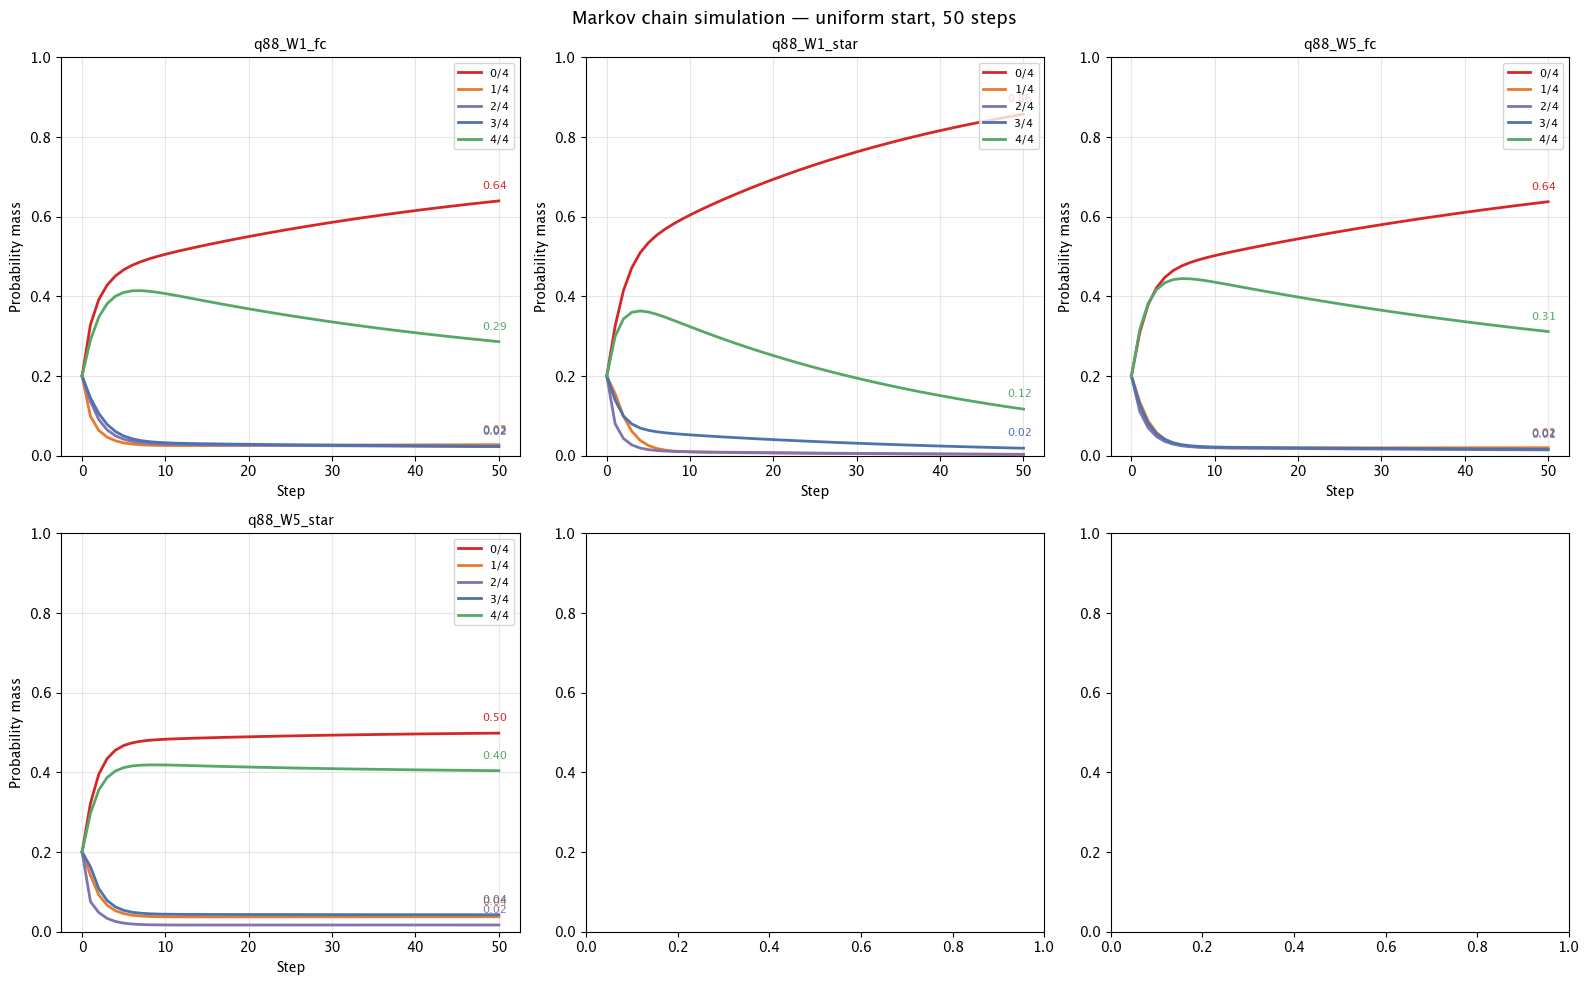

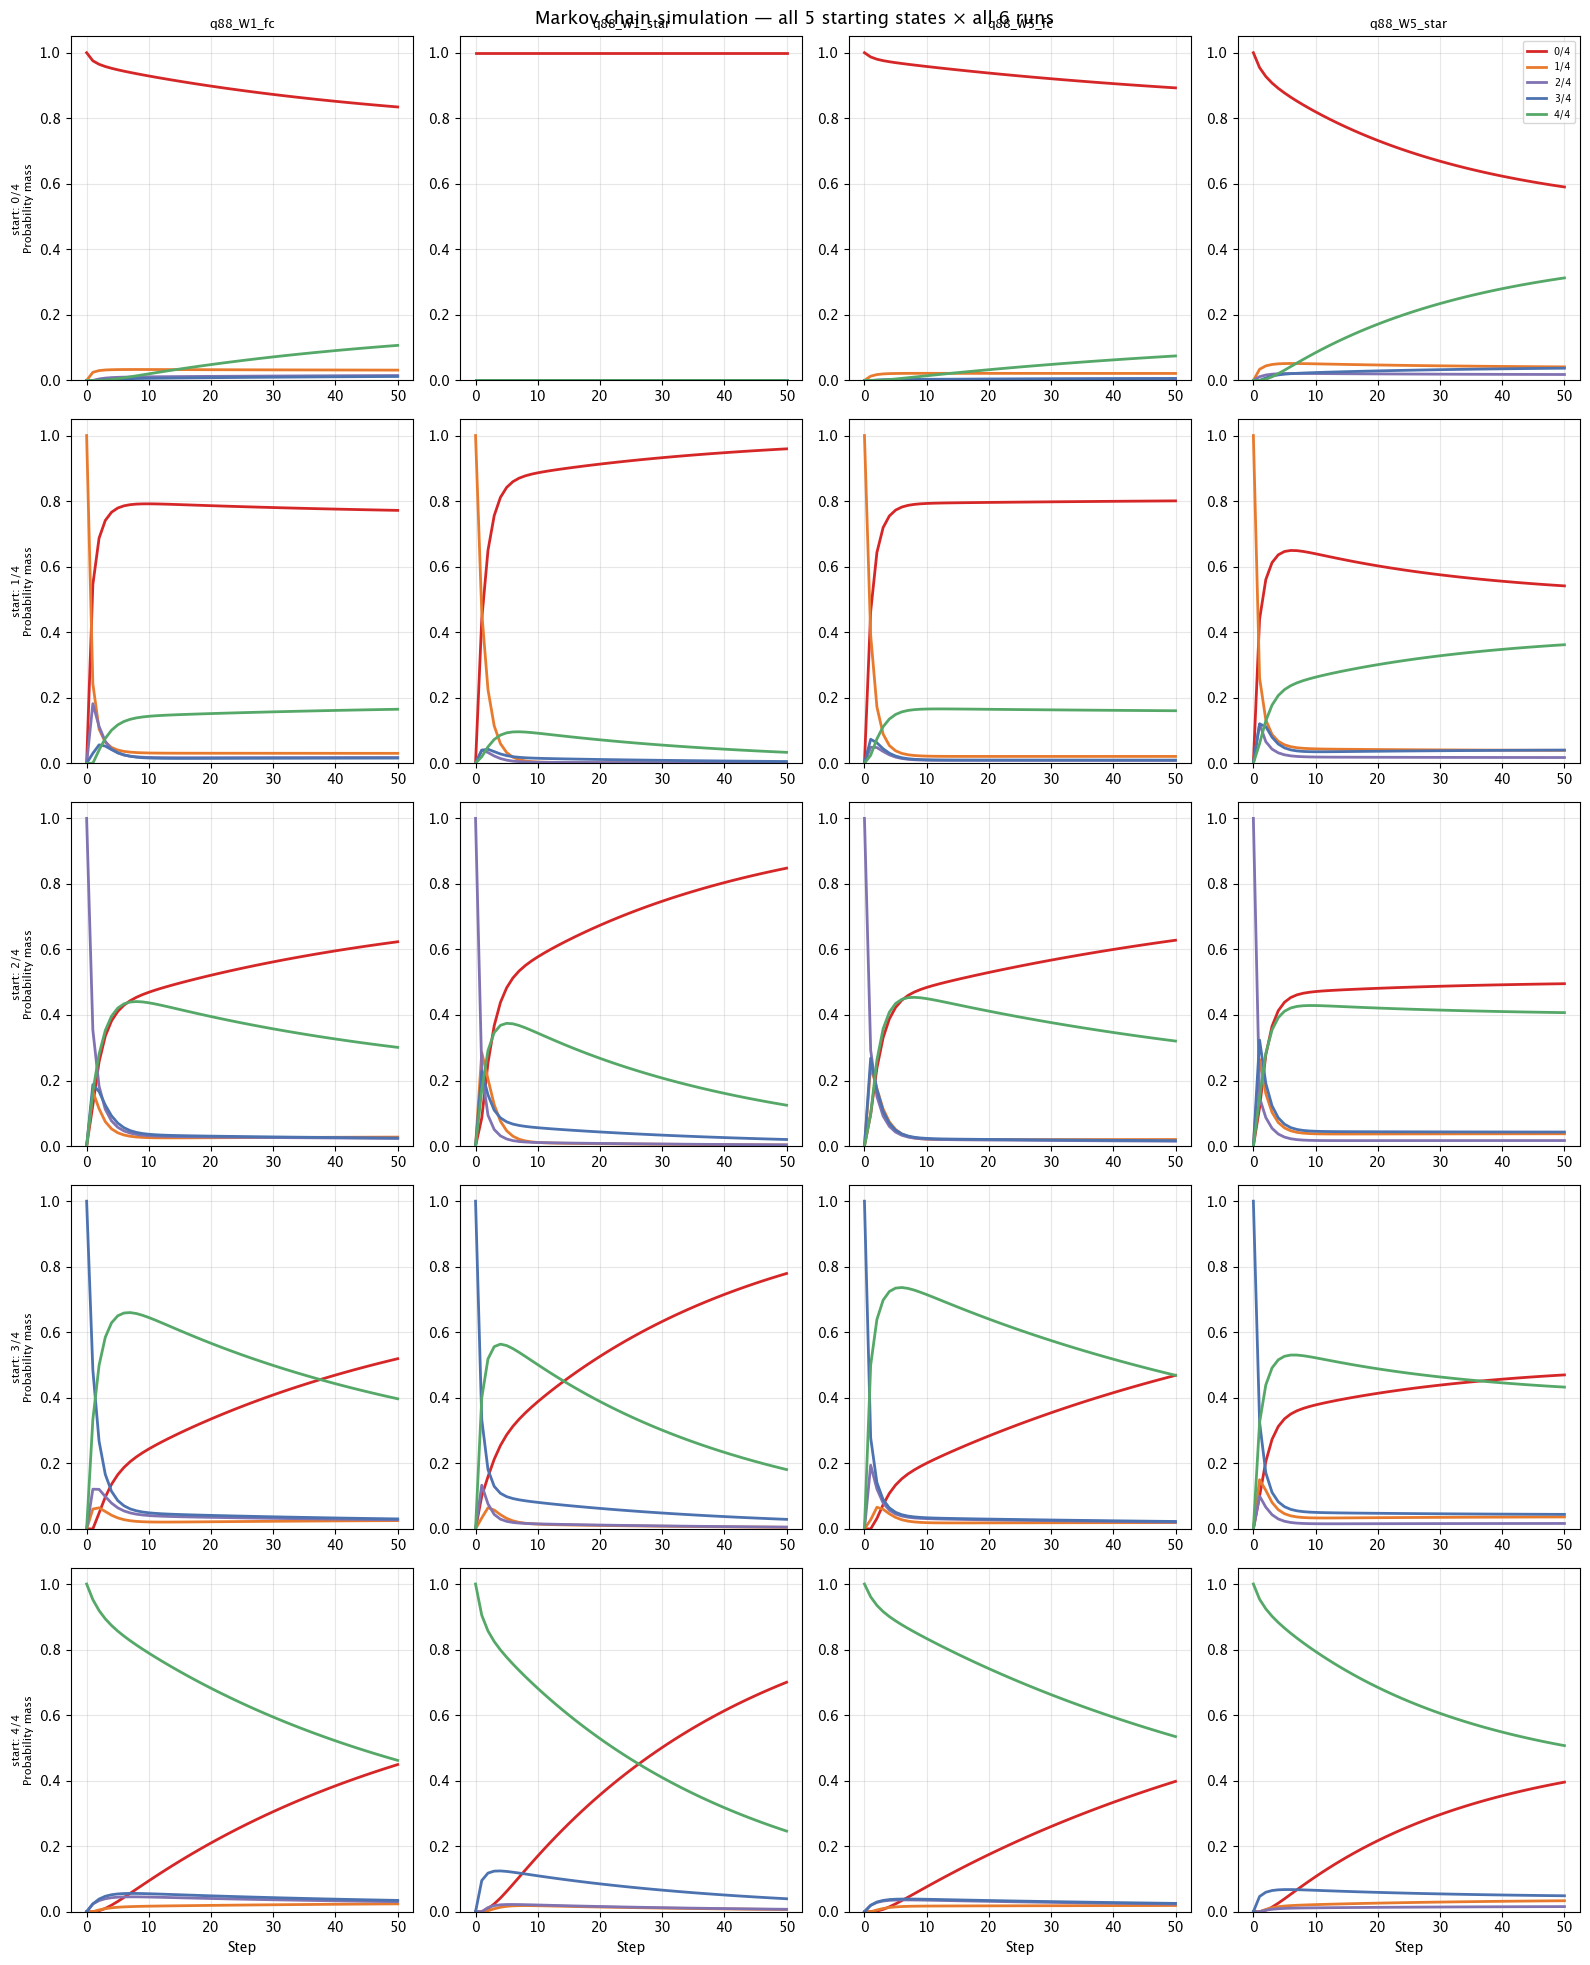

In [16]:
N_STATES = 5
steps = 50

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

state_colors = ['#d62728', '#e87a2e', '#8172B2', '#4C72B0', '#55A868']
state_labels = [f'{k}/4' for k in range(N_STATES)]

for ax, (name, d) in zip(axes, data.items()):
    T, _ = matrices[name]

    # start uniform over all 5 states
    pi = np.ones(N_STATES) / N_STATES

    history = [pi.copy()]
    for _ in range(steps):
        pi = pi @ T
        history.append(pi.copy())

    history = np.array(history)  # (steps+1, N_STATES)

    for k in range(N_STATES):
        ax.plot(history[:, k], color=state_colors[k], label=state_labels[k], linewidth=2)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Step')
    ax.set_ylabel('Probability mass')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

    # annotate final absorbing distribution
    final = history[-1]
    for k in range(N_STATES):
        if final[k] > 0.01:
            ax.annotate(f'{final[k]:.2f}', xy=(steps, final[k]),
                        xytext=(steps - 2, final[k] + 0.03),
                        fontsize=8, color=state_colors[k])

plt.suptitle(f'Markov chain simulation — uniform start, {steps} steps', fontsize=13)
plt.tight_layout()
plt.show()

# also: what if we start fully correct (4/4) or fully wrong (0/4)?
fig, axes = plt.subplots(N_STATES, len(data), figsize=(4 * len(data), 4 * N_STATES))

state_colors = ['#d62728', '#e87a2e', '#8172B2', '#4C72B0', '#55A868']
state_labels = [f'{k}/4' for k in range(N_STATES)]

for row, start in enumerate(range(N_STATES)):
    for col, (name, d) in enumerate(data.items()):
        ax = axes[row, col]
        T, _ = matrices[name]

        pi = np.zeros(N_STATES)
        pi[start] = 1.0

        history = [pi.copy()]
        for _ in range(steps):
            pi = pi @ T
            history.append(pi.copy())
        history = np.array(history)

        for k in range(N_STATES):
            ax.plot(history[:, k], color=state_colors[k], label=state_labels[k], linewidth=2)

        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

        if row == 0:
            ax.set_title(name, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'start: {start}/4\nProbability mass', fontsize=8)
        if row == N_STATES - 1:
            ax.set_xlabel('Step')
        if row == 0 and col == len(data) - 1:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Markov chain simulation — all 5 starting states × all 6 runs', fontsize=13)
plt.tight_layout()
plt.show()



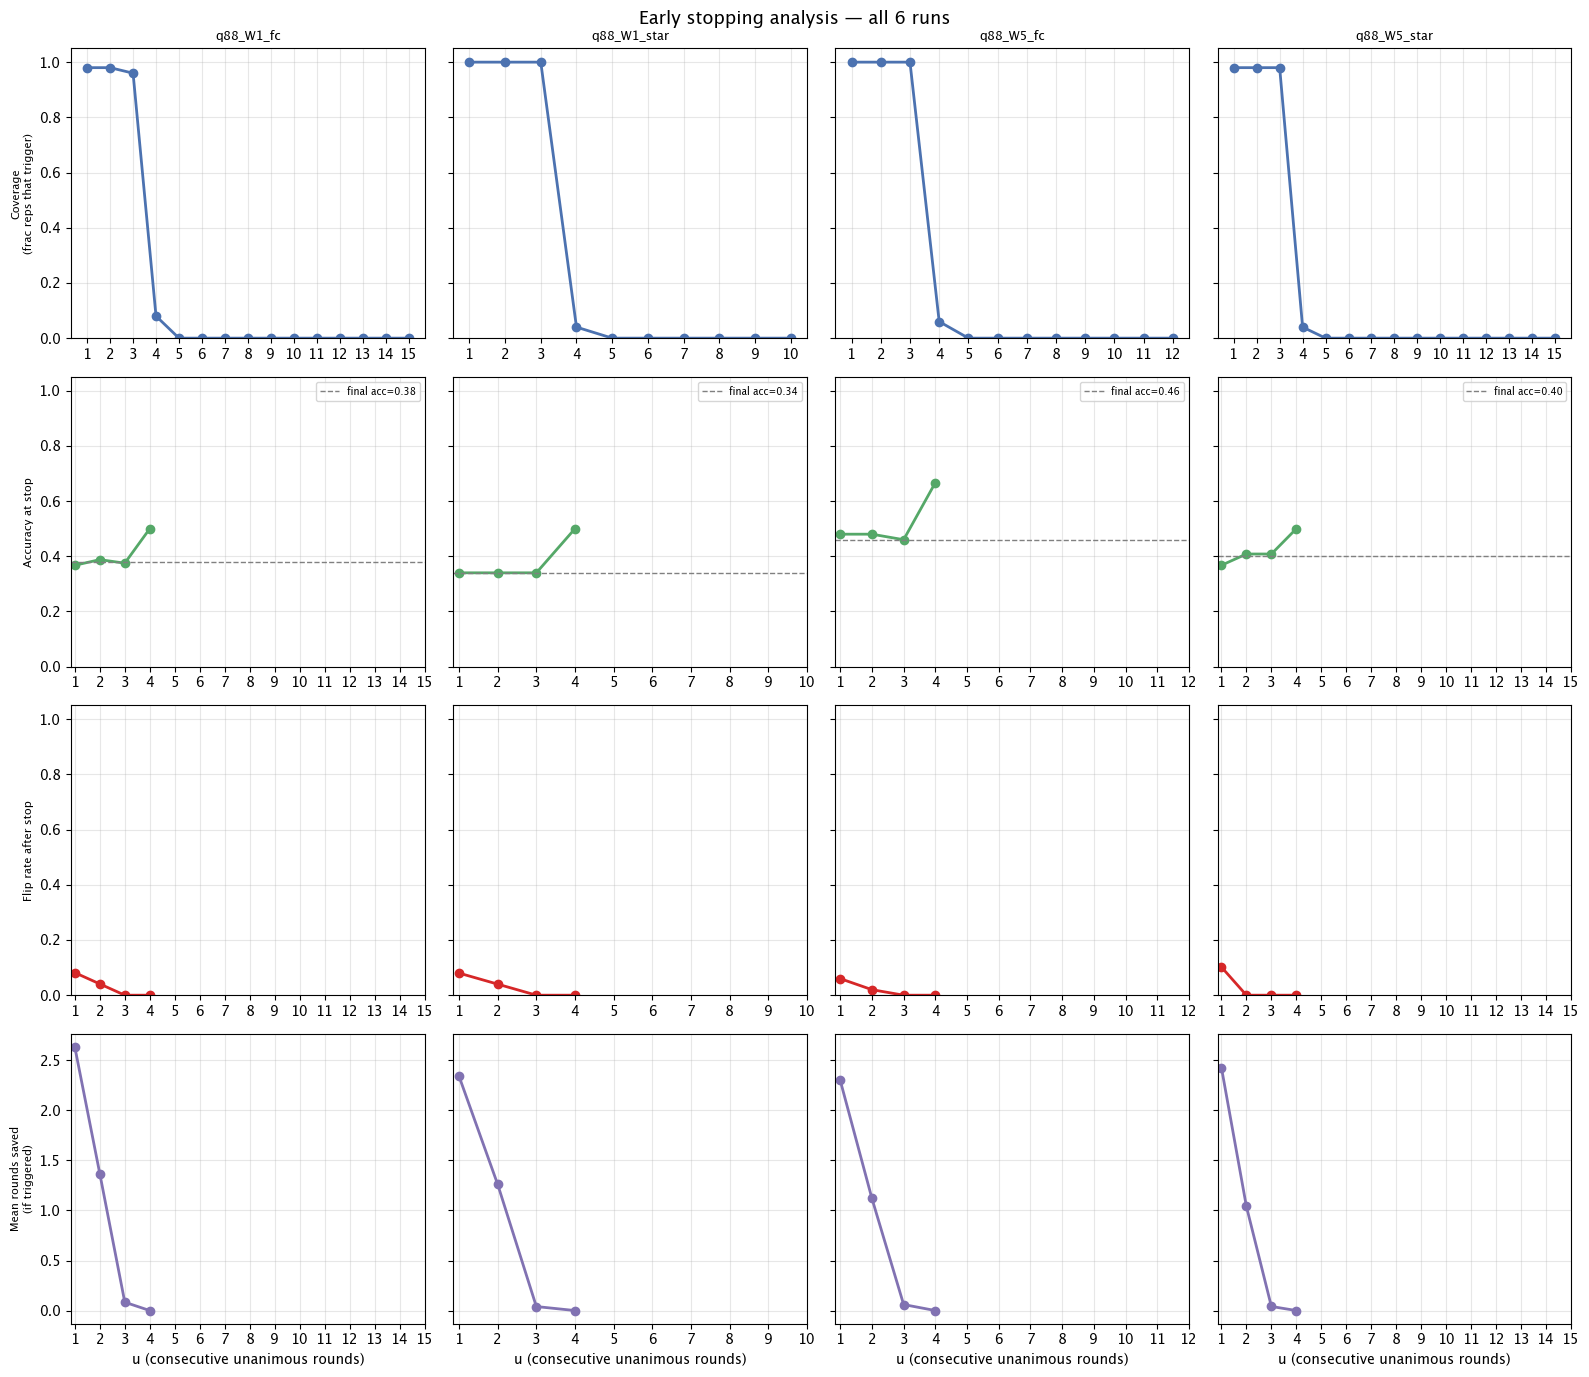

=== Summary: stop_accuracy vs final_accuracy at each u ===

q88_W1_fc  (final_acc=0.380)
 u  coverage  stop_accuracy  flip_rate  mean_rounds_saved_if_triggered
 1      0.98          0.367      0.082                           2.633
 2      0.98          0.388      0.041                           1.367
 3      0.96          0.375      0.000                           0.083
 4      0.08          0.500      0.000                           0.000
 5      0.00            NaN        NaN                             NaN
 6      0.00            NaN        NaN                             NaN
 7      0.00            NaN        NaN                             NaN
 8      0.00            NaN        NaN                             NaN
 9      0.00            NaN        NaN                             NaN
10      0.00            NaN        NaN                             NaN
11      0.00            NaN        NaN                             NaN
12      0.00            NaN        NaN                     

In [17]:
def early_stopping_analysis(d, max_u=None):
    gt = d['ground_truth']
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    if max_u is None:
        max_u = T - 1

    rows = []
    for u in range(1, max_u + 1):
        triggered, stop_correct, flipped, rounds_saved = [], [], [], []

        for rep in d['repetitions']:
            seq = unanimity_seq(rep)
            rep_T = len(seq)

            first_hit = next(
                (t for t in range(u - 1, rep_T) if all(seq[t - u + 1: t + 1])),
                None
            )

            if first_hit is None:
                triggered.append(False)
                continue

            triggered.append(True)
            stop_vote = votes_at(rep, first_hit)[0]
            stop_correct.append(stop_vote == gt)
            rounds_saved.append(rep_T - 1 - first_hit)

            later = seq[first_hit + 1:]
            flipped.append(any(not s for s in later))

        n = len(d['repetitions'])
        n_trig = sum(triggered)
        rows.append({
            'u': u,
            'coverage': n_trig / n,
            'stop_accuracy': np.mean(stop_correct) if stop_correct else float('nan'),
            'flip_rate': np.mean(flipped) if flipped else float('nan'),
            'mean_rounds_saved': np.mean(rounds_saved + [0] * (n - n_trig)),
            'mean_rounds_saved_if_triggered': np.mean(rounds_saved) if rounds_saved else float('nan'),
        })

    return pd.DataFrame(rows)

final_accs = {name: np.mean([rep['correct'] for rep in d['repetitions']]) for name, d in data.items()}
stats = {name: early_stopping_analysis(d) for name, d in data.items()}

fig, axes = plt.subplots(4, len(data), figsize=(4 * len(data), 14), sharey='row')

metrics = [
    ('coverage',                      'Coverage\n(frac reps that trigger)',  '#4C72B0'),
    ('stop_accuracy',                 'Accuracy at stop',                    '#55A868'),
    ('flip_rate',                     'Flip rate after stop',                '#d62728'),
    ('mean_rounds_saved_if_triggered','Mean rounds saved\n(if triggered)',   '#8172B2'),
]

for col, (name, d) in enumerate(data.items()):
    df = stats[name]
    final_acc = final_accs[name]

    for row, (metric, ylabel, color) in enumerate(metrics):
        ax = axes[row, col]
        ax.plot(df['u'], df[metric], marker='o', color=color, linewidth=2)

        if metric == 'stop_accuracy':
            ax.axhline(final_acc, color='gray', linestyle='--', linewidth=1, label=f'final acc={final_acc:.2f}')
            ax.legend(fontsize=7)
        if metric in ('coverage', 'stop_accuracy', 'flip_rate'):
            ax.set_ylim(0, 1.05)

        ax.set_xticks(df['u'])
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(name, fontsize=9)
        if row == len(metrics) - 1:
            ax.set_xlabel('u (consecutive unanimous rounds)')
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Early stopping analysis — all 6 runs', fontsize=13)
plt.tight_layout()
plt.show()

print("=== Summary: stop_accuracy vs final_accuracy at each u ===")
for name, df in stats.items():
    print(f"\n{name}  (final_acc={final_accs[name]:.3f})")
    print(df[['u','coverage','stop_accuracy','flip_rate','mean_rounds_saved_if_triggered']].round(3).to_string(index=False))


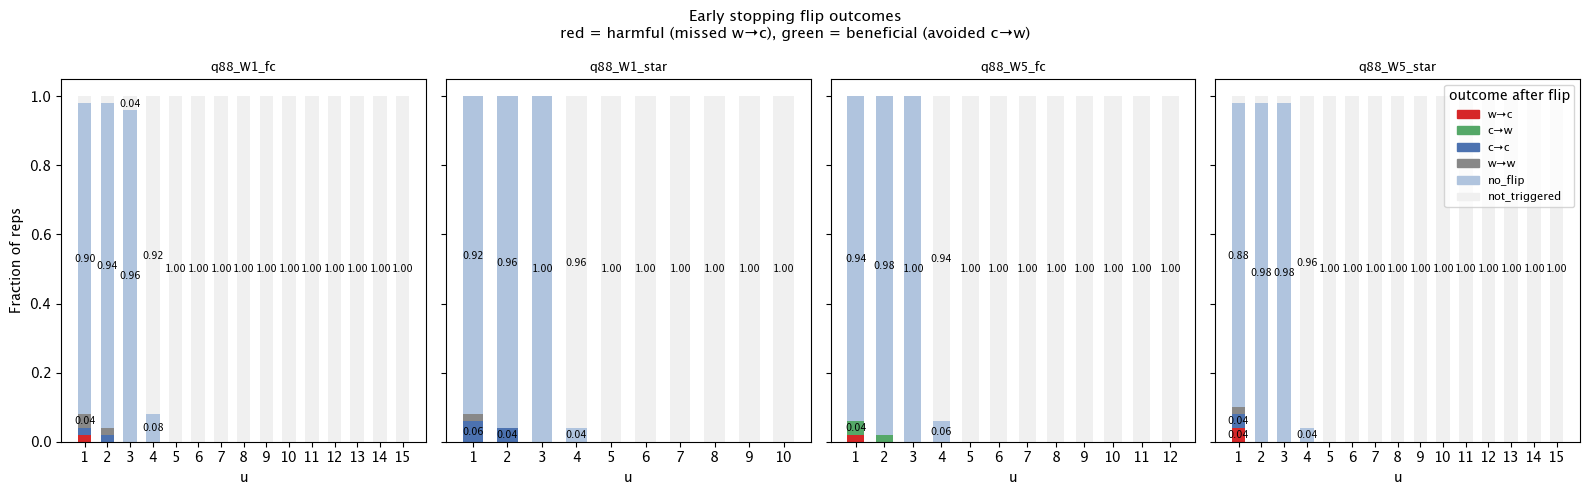

=== w→c (harmful) and c→w (beneficial) rates ===

q88_W1_fc
 u  w→c  c→w  c→c  w→w  no_flip  not_triggered
 1 0.02  0.0 0.02 0.04     0.90           0.02
 2 0.00  0.0 0.02 0.02     0.94           0.02
 3 0.00  0.0 0.00 0.00     0.96           0.04
 4 0.00  0.0 0.00 0.00     0.08           0.92
 5 0.00  0.0 0.00 0.00     0.00           1.00
 6 0.00  0.0 0.00 0.00     0.00           1.00
 7 0.00  0.0 0.00 0.00     0.00           1.00
 8 0.00  0.0 0.00 0.00     0.00           1.00
 9 0.00  0.0 0.00 0.00     0.00           1.00
10 0.00  0.0 0.00 0.00     0.00           1.00
11 0.00  0.0 0.00 0.00     0.00           1.00
12 0.00  0.0 0.00 0.00     0.00           1.00
13 0.00  0.0 0.00 0.00     0.00           1.00
14 0.00  0.0 0.00 0.00     0.00           1.00
15 0.00  0.0 0.00 0.00     0.00           1.00

q88_W1_star
 u  w→c  c→w  c→c  w→w  no_flip  not_triggered
 1  0.0  0.0 0.06 0.02     0.92           0.00
 2  0.0  0.0 0.04 0.00     0.96           0.00
 3  0.0  0.0 0.00 0.00     1.00   

In [18]:
def early_stopping_flip_outcomes(d, max_u=None):
    gt = d['ground_truth']
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    if max_u is None:
        max_u = T - 1

    rows = []
    for u in range(1, max_u + 1):
        outcomes = {'c→c': 0, 'c→w': 0, 'w→c': 0, 'w→w': 0, 'no_flip': 0, 'not_triggered': 0}

        for rep in d['repetitions']:
            seq = unanimity_seq(rep)
            rep_T = len(seq)

            first_hit = next(
                (t for t in range(u - 1, rep_T) if all(seq[t - u + 1: t + 1])),
                None
            )

            if first_hit is None:
                outcomes['not_triggered'] += 1
                continue

            stop_correct = votes_at(rep, first_hit)[0] == gt
            later = seq[first_hit + 1:]
            has_flip = any(not s for s in later)

            if not has_flip:
                outcomes['no_flip'] += 1
                continue

            final_correct = majority_vote(rep, -1) == gt
            key = f"{'c' if stop_correct else 'w'}→{'c' if final_correct else 'w'}"
            outcomes[key] += 1

        n = len(d['repetitions'])
        rows.append({'u': u, **{k: v / n for k, v in outcomes.items()}})

    return pd.DataFrame(rows)

flip_stats = {name: early_stopping_flip_outcomes(d) for name, d in data.items()}

outcome_colors = {
    'w→c': '#d62728',   # harmful: missed recovery
    'c→w': '#55A868',   # beneficial: avoided degradation
    'c→c': '#4C72B0',   # flip but recovered, fine
    'w→w': '#888888',   # flip but stayed wrong, neutral
    'no_flip': '#b0c4de',
    'not_triggered': '#f0f0f0',
}

fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 5), sharey=True)

for ax, (name, df) in zip(axes, flip_stats.items()):
    bottom = np.zeros(len(df))
    for outcome, color in outcome_colors.items():
        vals = df[outcome].values
        bars = ax.bar(df['u'], vals, bottom=bottom, color=color, label=outcome, width=0.6)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.03:
                ax.text(df['u'].iloc[i], b + v / 2, f'{v:.2f}', ha='center', va='center', fontsize=7)
        bottom += vals

    ax.set_title(name, fontsize=9)
    ax.set_xlabel('u')
    ax.set_xticks(df['u'])
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel('Fraction of reps')
axes[-1].legend(
    loc='upper right', fontsize=8,
    title='outcome after flip',
    handles=[plt.Rectangle((0,0),1,1, color=c, label=k) for k, c in outcome_colors.items()]
)
plt.suptitle('Early stopping flip outcomes\nred = harmful (missed w→c), green = beneficial (avoided c→w)', fontsize=11)
plt.tight_layout()
plt.show()

print("=== w→c (harmful) and c→w (beneficial) rates ===")
for name, df in flip_stats.items():
    print(f"\n{name}")
    print(df[['u', 'w→c', 'c→w', 'c→c', 'w→w', 'no_flip', 'not_triggered']].round(3).to_string(index=False))


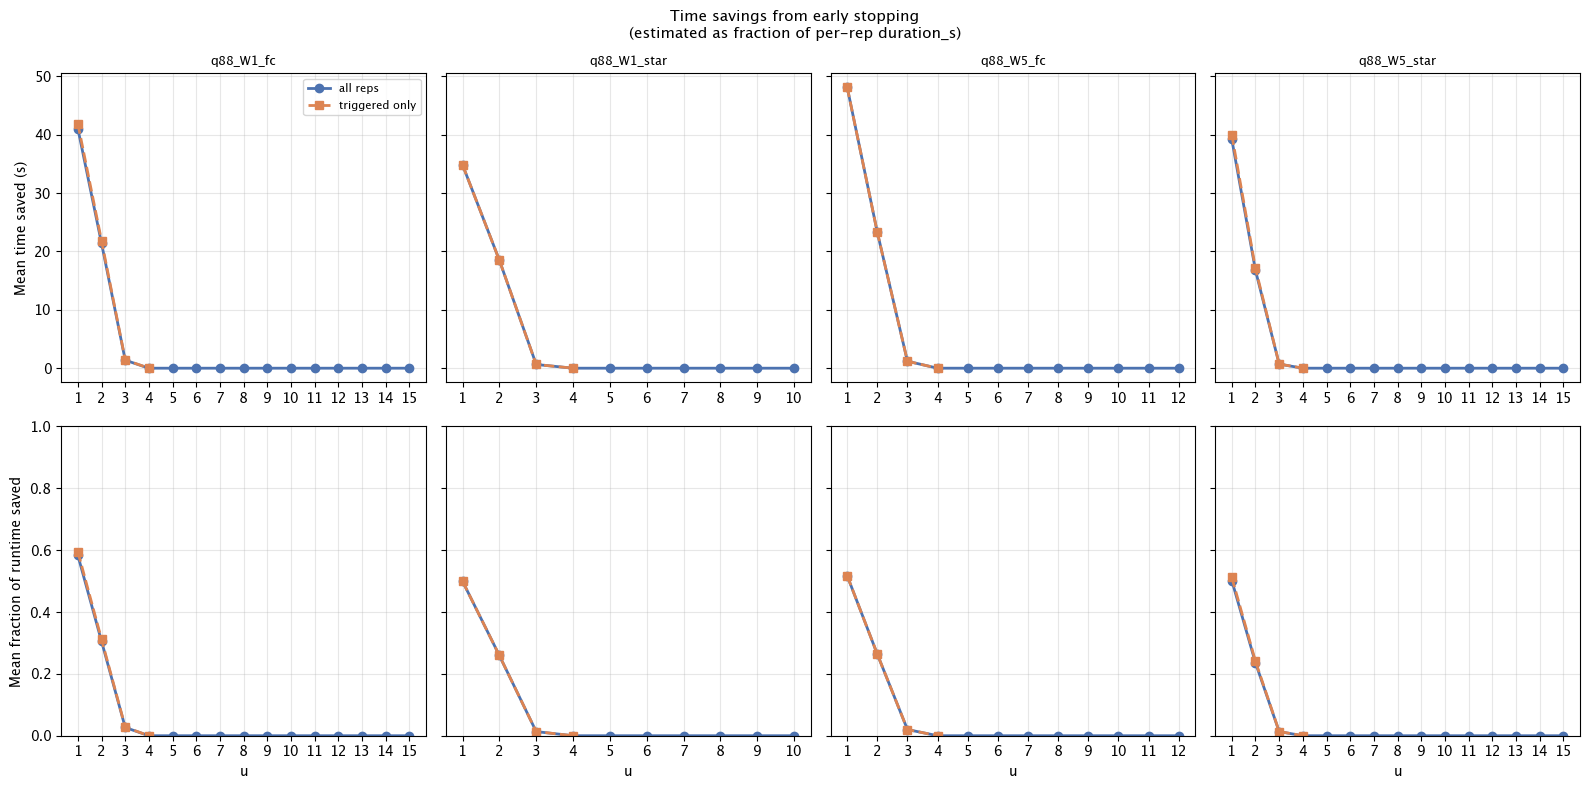

=== Time savings summary ===

q88_W1_fc  (mean rep duration: 73.9s)
 u  coverage  mean_frac_saved  mean_time_saved_s  mean_time_saved_s_if_triggered
 1      0.98            0.583             41.043                          41.880
 2      0.98            0.305             21.378                          21.815
 3      0.96            0.027              1.371                           1.429
 4      0.08            0.000              0.000                           0.000
 5      0.00            0.000              0.000                             NaN
 6      0.00            0.000              0.000                             NaN
 7      0.00            0.000              0.000                             NaN
 8      0.00            0.000              0.000                             NaN
 9      0.00            0.000              0.000                             NaN
10      0.00            0.000              0.000                             NaN
11      0.00            0.000            

In [19]:
def early_stopping_time_savings(d, max_u=None):
    gt = d['ground_truth']
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    if max_u is None:
        max_u = T - 1

    rows = []
    for u in range(1, max_u + 1):
        time_saved_all, time_saved_triggered, frac_saved_all, frac_saved_triggered = [], [], [], []

        for rep in d['repetitions']:
            seq = unanimity_seq(rep)
            rep_T = len(seq)          # T+1 steps, rounds 0..T
            total_rounds = rep_T - 1  # T actual discussion rounds
            dur = rep['duration_s']

            first_hit = next(
                (t for t in range(u - 1, rep_T) if all(seq[t - u + 1: t + 1])),
                None
            )

            if first_hit is None:
                time_saved_all.append(0)
                frac_saved_all.append(0)
                continue

            rounds_saved = total_rounds - first_hit
            frac = rounds_saved / total_rounds
            estimated_time_saved = frac * dur

            time_saved_all.append(estimated_time_saved)
            time_saved_triggered.append(estimated_time_saved)
            frac_saved_all.append(frac)
            frac_saved_triggered.append(frac)

        rows.append({
            'u': u,
            'mean_time_saved_s': np.mean(time_saved_all),
            'mean_time_saved_s_if_triggered': np.mean(time_saved_triggered) if time_saved_triggered else float('nan'),
            'mean_frac_saved': np.mean(frac_saved_all),
            'mean_frac_saved_if_triggered': np.mean(frac_saved_triggered) if frac_saved_triggered else float('nan'),
            'coverage': len(time_saved_triggered) / len(d['repetitions']),
        })

    return pd.DataFrame(rows)

time_stats = {name: early_stopping_time_savings(d) for name, d in data.items()}

fig, axes = plt.subplots(2, len(data), figsize=(4 * len(data), 8), sharey='row')

for col, (name, df) in enumerate(time_stats.items()):
    ax_time = axes[0, col]
    ax_frac = axes[1, col]

    ax_time.plot(df['u'], df['mean_time_saved_s'], marker='o', color='#4C72B0', label='all reps', linewidth=2)
    ax_time.plot(df['u'], df['mean_time_saved_s_if_triggered'], marker='s', color='#DD8452', label='triggered only', linewidth=2, linestyle='--')
    ax_time.set_title(name, fontsize=9)
    ax_time.set_xticks(df['u'])
    ax_time.grid(alpha=0.3)

    ax_frac.plot(df['u'], df['mean_frac_saved'], marker='o', color='#4C72B0', linewidth=2)
    ax_frac.plot(df['u'], df['mean_frac_saved_if_triggered'], marker='s', color='#DD8452', linewidth=2, linestyle='--')
    ax_frac.set_xlabel('u')
    ax_frac.set_xticks(df['u'])
    ax_frac.set_ylim(0, 1)
    ax_frac.grid(alpha=0.3)

    if col == 0:
        axes[0, col].set_ylabel('Mean time saved (s)')
        axes[1, col].set_ylabel('Mean fraction of runtime saved')
        axes[0, col].legend(fontsize=8)

plt.suptitle('Time savings from early stopping\n(estimated as fraction of per-rep duration_s)', fontsize=11)
plt.tight_layout()
plt.show()

print("=== Time savings summary ===")
for name, df in time_stats.items():
    total_avg = np.mean([rep['duration_s'] for rep in data[name]['repetitions']])
    print(f"\n{name}  (mean rep duration: {total_avg:.1f}s)")
    print(df[['u','coverage','mean_frac_saved','mean_time_saved_s','mean_time_saved_s_if_triggered']].round(3).to_string(index=False))


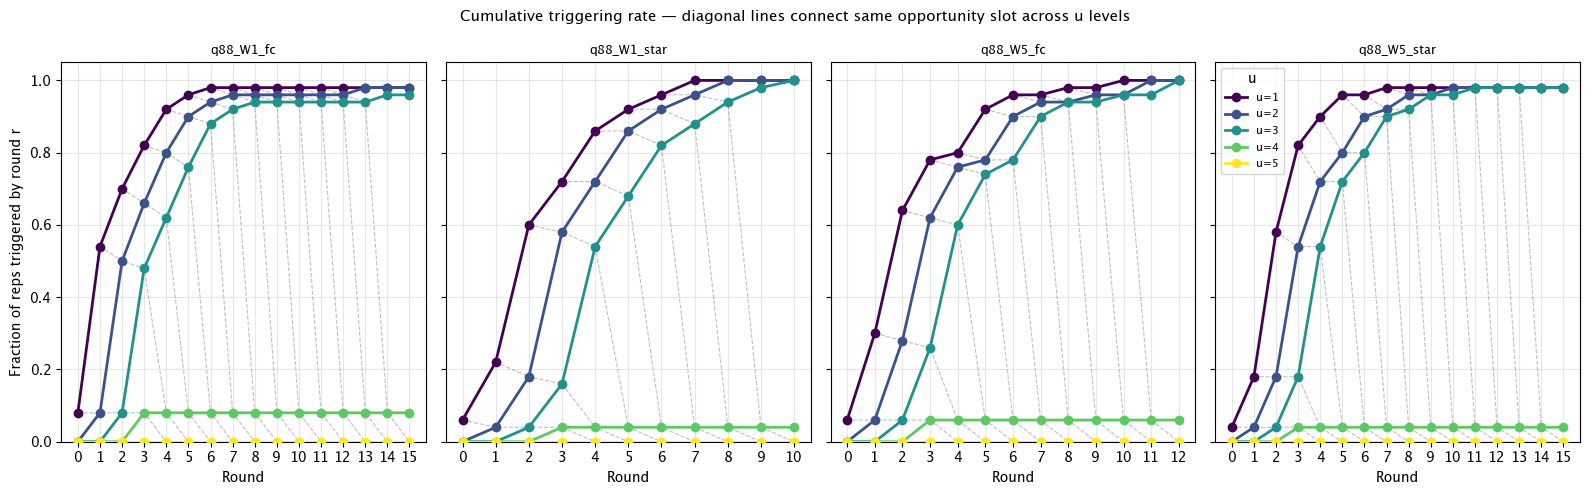

In [20]:
fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 5), sharey=True)

max_u = 5
cmap = plt.cm.viridis
u_colors = [cmap(i / (max_u - 1)) for i in range(max_u)]

for ax, (name, d) in zip(axes, data.items()):
    T = max(len(rep['trajectory']) for rep in d['repetitions'])
    rounds = np.arange(T)

    all_cumulative = {}
    for u, color in zip(range(1, max_u + 1), u_colors):
        first_hits = []
        for rep in d['repetitions']:
            seq = unanimity_seq(rep)
            rep_T = len(seq)
            first_hit = next(
                (t for t in range(u - 1, rep_T) if all(seq[t - u + 1: t + 1])),
                None
            )
            if first_hit is not None:
                first_hits.append(first_hit)

        cumulative = [sum(h <= r for h in first_hits) / len(d['repetitions']) for r in rounds]
        all_cumulative[u] = cumulative
        ax.plot(rounds, cumulative, marker='o', color=color, label=f'u={u}', linewidth=2, zorder=3)

    # diagonal connectors: line k connects (r=k, u=1) -> (r=k+1, u=2) -> (r=k+2, u=3) ...
    for k in range(T - max_u + 1):
        xs = [k + (u - 1) for u in range(1, max_u + 1)]
        ys = [all_cumulative[u][k + (u - 1)] for u in range(1, max_u + 1) if k + (u - 1) < T]
        xs = xs[:len(ys)]
        ax.plot(xs, ys, linestyle='--', color='gray', linewidth=0.8, alpha=0.5, zorder=2)

    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Round')
    ax.set_xticks(range(T))
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Fraction of reps triggered by round r')
axes[-1].legend(title='u', fontsize=8)
plt.suptitle('Cumulative triggering rate — diagonal lines connect same opportunity slot across u levels', fontsize=11)
plt.tight_layout()
plt.show()
